In [8]:
#setting the Environment
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [48]:
# Load the dataset
df = pd.read_csv('E_Commerce_Data_Set_4034.csv')
df.head()

,Genre,Age,Annual_Income (£K),Spending_Score
0,Male,24.0,62.0,13.0
1,Male,52.0,59.0,35.0
2,Female,42.0,31.0,12.0
3,Female,20.0,92.0,41.0
4,Female,30.0,52.0,40.0


In [12]:
# Explore the data
print("Dataset Preview:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDescriptive Statistics:")
print(df.describe())
print("\nNull Values in DataSet:")
print(df.isnull().sum())

Dataset Preview:
    Genre   Age  Annual_Income (£K)  Spending_Score
0    Male  24.0                62.0            13.0
1    Male  52.0                59.0            35.0
2  Female  42.0                31.0            12.0
3  Female  20.0                92.0            41.0
4  Female  30.0                52.0            40.0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Genre               800 non-null    object 
 1   Age                 775 non-null    float64
 2   Annual_Income (£K)  781 non-null    float64
 3   Spending_Score      785 non-null    float64
dtypes: float64(3), object(1)
memory usage: 25.1+ KB
None

Descriptive Statistics:
              Age  Annual_Income (£K)  Spending_Score
count  775.000000          781.000000      785.000000
mean    42.452903           68.288092       31.433121
std     14.26

In [54]:
# Preprocess the data
numerical_cols = ['Age', 'Annual_Income (£K)', 'Spending_Score']
df = df.dropna(subset=numerical_cols)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numerical_cols])

In [56]:
print(df_scaled)

[[-1.29187001 -0.20552795 -1.05506947]
 [ 0.68757899 -0.3064532   0.16763207]
 [-0.01936708 -1.24842224 -1.11064681]
 ...
 [ 0.33410596  1.03921686 -1.66642024]
 [-0.37284012  0.16453132  1.33475626]
 [ 0.61688439 -1.38298925  1.3903336 ]]


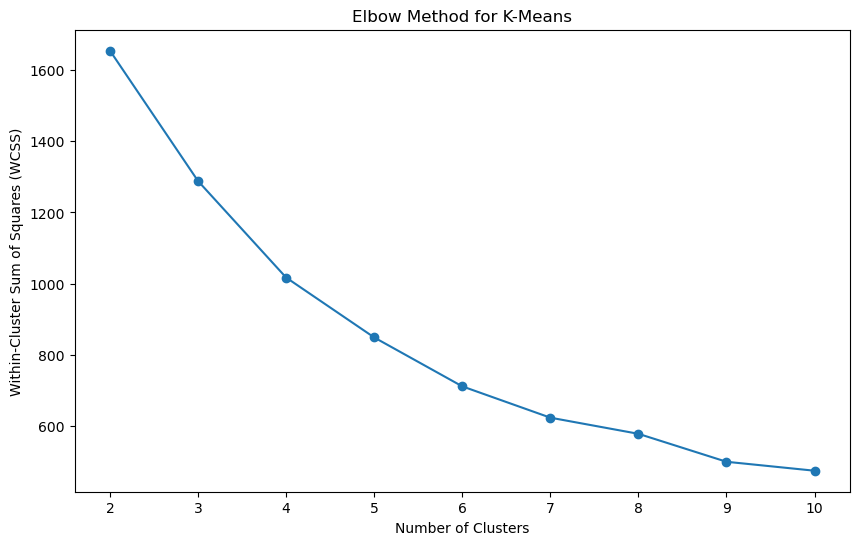

In [18]:
# K-Means Clustering
# Elbow method to find optimal number of clusters
wcss = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for K-Means')
#plt.savefig('elbow_method_kmeans.png')
plt.show()

In [58]:
# Fit K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(df_scaled)
silhouette_kmeans = silhouette_score(df_scaled, df['KMeans_Cluster'])
print(f"K-Means Silhouette Score: {silhouette_kmeans}")


K-Means Silhouette Score: 0.25468752920815946


In [60]:
# Analyze K-Means clusters
cluster_means_kmeans = df.groupby('KMeans_Cluster')[numerical_cols].mean()
print("\nK-Means Cluster Means:")
print(cluster_means_kmeans)


K-Means Cluster Means:
                      Age  Annual_Income (£K)  Spending_Score
KMeans_Cluster                                               
0               33.953191           98.519149       35.625532
1               35.702479           42.256198       39.326446
2               55.704545           64.738636       22.011364


In [62]:
# Hierarchical Clustering
# Fit Hierarchical Clustering with K=3
hclust = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['HClust_Cluster'] = hclust.fit_predict(df_scaled)
silhouette_hclust = silhouette_score(df_scaled, df['HClust_Cluster'])
print(f"Hierarchical Clustering Silhouette Score: {silhouette_hclust}")


Hierarchical Clustering Silhouette Score: 0.22857015503774272


In [26]:
# Analyze Hierarchical Clustering clusters
cluster_means_hclust = df.groupby('HClust_Cluster')[numerical_cols].mean()
print("\nHierarchical Clustering Cluster Means:")
print(cluster_means_hclust)


Hierarchical Clustering Cluster Means:
                      Age  Annual_Income (£K)  Spending_Score
HClust_Cluster                                               
0               40.772080           93.074074       35.492877
1               46.438298           48.868085       15.395745
2               39.361290           40.748387       49.187097


In [68]:
# DBSCAN Clustering
# Fit DBSCAN with eps=0.5, min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(df_scaled)
# Check if DBSCAN produced valid clusters (at least 2 clusters, excluding noise)
if len(np.unique(df['DBSCAN_Cluster'][df['DBSCAN_Cluster'] != -1])) > 1:
    silhouette_dbscan = silhouette_score(df_scaled[df['DBSCAN_Cluster'] != -1], 
                                        df['DBSCAN_Cluster'][df['DBSCAN_Cluster'] != -1])
    print(f"DBSCAN Silhouette Score: {silhouette_dbscan}")
else:
    print("DBSCAN produced fewer than 2 clusters or too many noise points.")
    silhouette_dbscan = None

DBSCAN Silhouette Score: -0.14428499314657756


In [70]:
# Analyze DBSCAN clusters (excluding noise points)
if silhouette_dbscan is not None:
    cluster_means_dbscan = df[df['DBSCAN_Cluster'] != -1].groupby('DBSCAN_Cluster')[numerical_cols].mean()
    print("\nDBSCAN Cluster Means:")
    print(cluster_means_dbscan)


DBSCAN Cluster Means:
                      Age  Annual_Income (£K)  Spending_Score
DBSCAN_Cluster                                               
0               42.392012           70.892012       32.109467
1               63.000000           47.500000       57.000000
2               24.458333           29.041667       15.291667
3               48.000000           37.250000       31.875000


In [72]:
# Gaussian Mixture Models
# Fit GMM with 3 components
gmm = GaussianMixture(n_components=3, random_state=42)
df['GMM_Cluster'] = gmm.fit_predict(df_scaled)
silhouette_gmm = silhouette_score(df_scaled, df['GMM_Cluster'])
print(f"GMM Silhouette Score: {silhouette_gmm}")


GMM Silhouette Score: 0.23465972917400482


In [74]:
# Analyze GMM clusters
cluster_means_gmm = df.groupby('GMM_Cluster')[numerical_cols].mean()
print("\nGMM Cluster Means:")
print(cluster_means_gmm)


GMM Cluster Means:
                   Age  Annual_Income (£K)  Spending_Score
GMM_Cluster                                               
0            32.325688           98.027523       33.766055
1            35.446494           45.014760       33.778598
2            58.222222           67.063492       28.511905


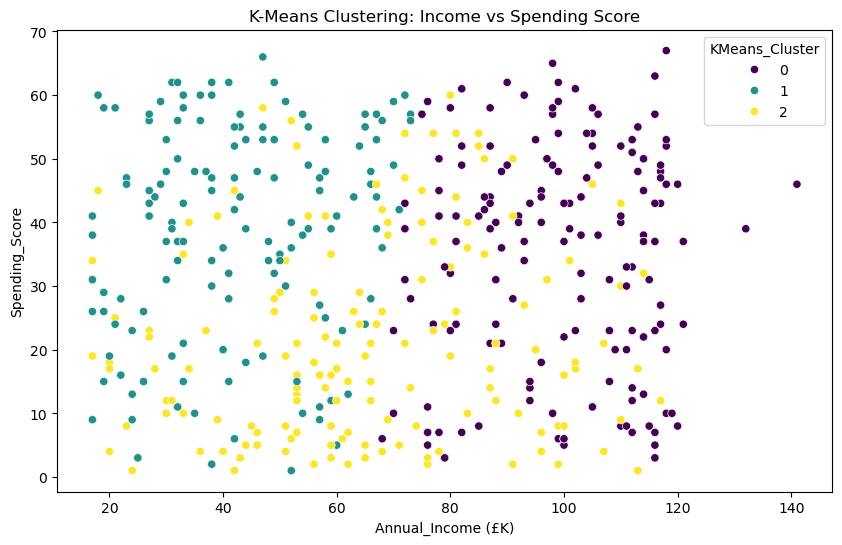

In [76]:
# Visualize clusters (Income vs Spending Score)
# K-Means
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income (£K)', y='Spending_Score', hue='KMeans_Cluster', palette='viridis')
plt.title('K-Means Clustering: Income vs Spending Score')
#plt.savefig('kmeans_clusters.png')
plt.show()

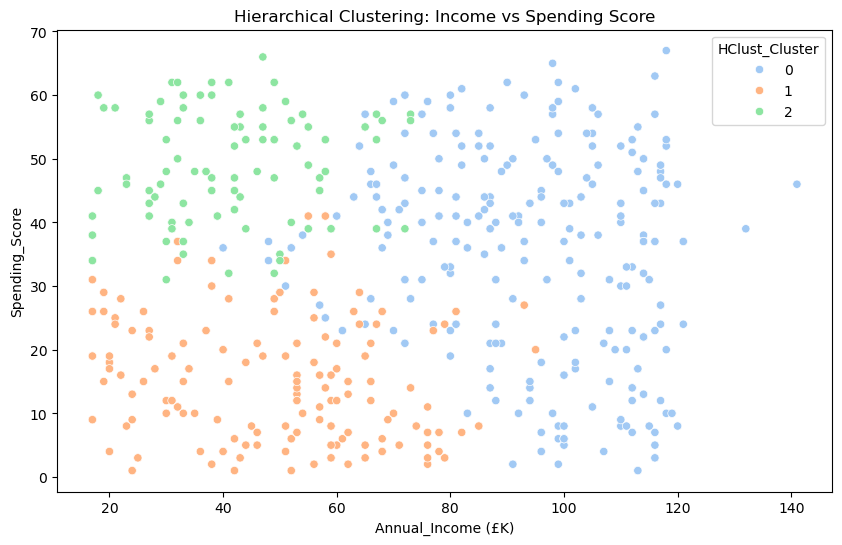

In [38]:
# Hierarchical
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income (£K)', y='Spending_Score', hue='HClust_Cluster', palette='pastel')
plt.title('Hierarchical Clustering: Income vs Spending Score')
#plt.savefig('hclust_clusters.png')
plt.show()

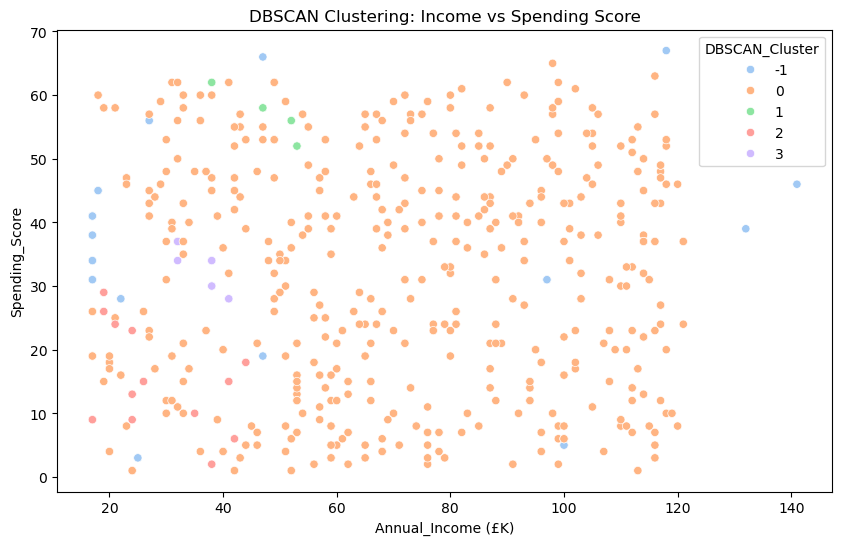

In [40]:
# DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income (£K)', y='Spending_Score', hue='DBSCAN_Cluster', palette='pastel')
plt.title('DBSCAN Clustering: Income vs Spending Score')
#plt.savefig('dbscan_clusters.png')
plt.show()

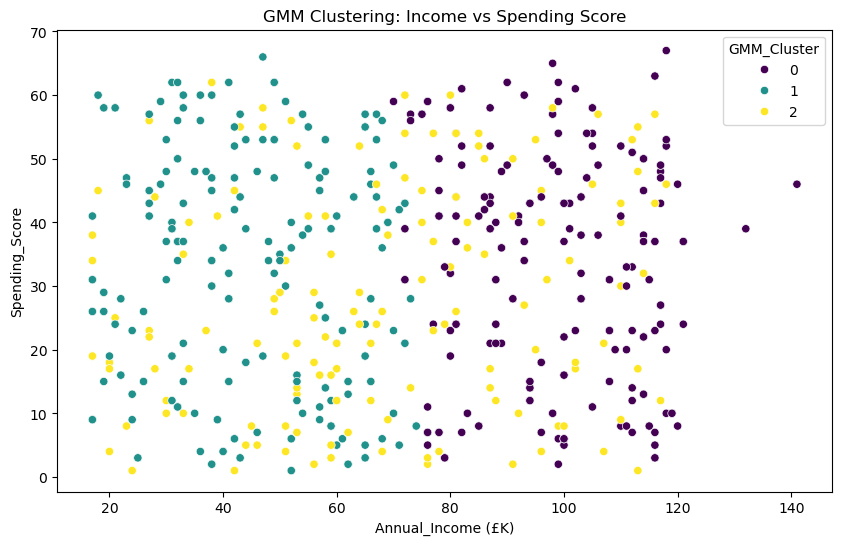

In [42]:
# GMM
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual_Income (£K)', y='Spending_Score', hue='GMM_Cluster', palette='viridis')
plt.title('GMM Clustering: Income vs Spending Score')
#plt.savefig('gmm_clusters.png')
plt.show()

In [78]:
# Analyze Genre distribution within clusters
print("\nGenre Distribution in K-Means Clusters:")
print(df.groupby('KMeans_Cluster')['Genre'].value_counts(normalize=True).unstack())
print("\nGenre Distribution in Hierarchical Clusters:")
print(df.groupby('HClust_Cluster')['Genre'].value_counts(normalize=True).unstack())
print("\nGenre Distribution in DBSCAN Clusters:")
print(df.groupby('DBSCAN_Cluster')['Genre'].value_counts(normalize=True).unstack())
print("\nGenre Distribution in GMM Clusters:")
print(df.groupby('GMM_Cluster')['Genre'].value_counts(normalize=True).unstack())


Genre Distribution in K-Means Clusters:
Genre             Female      Male
KMeans_Cluster                    
0               0.574468  0.425532
1               0.528926  0.471074
2               0.594697  0.405303

Genre Distribution in Hierarchical Clusters:
Genre             Female      Male
HClust_Cluster                    
0               0.575499  0.424501
1               0.544681  0.455319
2               0.580645  0.419355

Genre Distribution in DBSCAN Clusters:
Genre             Female      Male
DBSCAN_Cluster                    
-1              0.840000  0.160000
 0              0.551775  0.448225
 1              0.750000  0.250000
 2              0.500000  0.500000
 3              1.000000       NaN

Genre Distribution in GMM Clusters:
Genre          Female      Male
GMM_Cluster                    
0            0.564220  0.435780
1            0.531365  0.468635
2            0.607143  0.392857


In [82]:
# Compare clustering methods
print("\nClustering Method Comparison:")
comparison_data = {
    'Method': ['K-Means', 'Hierarchical', 'DBSCAN', 'GMM'],
    'Silhouette Score': [silhouette_kmeans, silhouette_hclust, 
                         silhouette_dbscan if silhouette_dbscan is not None else 'N/A', 
                         silhouette_gmm]
}
comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)


Clustering Method Comparison:
         Method  Silhouette Score
0       K-Means          0.254688
1  Hierarchical          0.228570
2        DBSCAN         -0.144285
3           GMM          0.234660
